SCENARIO 1 – CLUSTERING USING K-MEANS

Problem Statement
Group customers/data points into clusters based on similarity using K-Means clustering.

Dataset (Kaggle – Public)
Mall Customer Segmentation Dataset
Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
(You can use any dataset with numerical features)

Target Variable: Cluster labels (no predefined labels – unsupervised learning)
Input Feature:
• Annual Income
• Spending Score
• Age (optional)

IN-LAB TASKS
1.	Import required Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn)
2.	Load the dataset
3.	Perform data preprocessing (handling missing values, scaling)
4.	Select relevant features
5.	Use Elbow Method to determine optimal K
6.	Apply K-Means clustering
7.	Assign cluster labels
8.	Visualize clusters
9.	Interpret cluster characteristics

Evaluation Metrics
• Inertia (Within-cluster sum of squares)
• Silhouette Score

Analysis Tasks
• Observe how different K values affect clustering
• Analyze compactness and separation of clusters
• Identify customer segments (e.g., high income–high spending)
• Study sensitivity to initialization




Visualization
• Elbow curve (K vs inertia)
• Scatter plot of clusters
• Cluster centroids



Saving Mall_Customers.csv to Mall_Customers (3).csv
VETTRI SELVAN D - 24BAD127

Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Checking Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


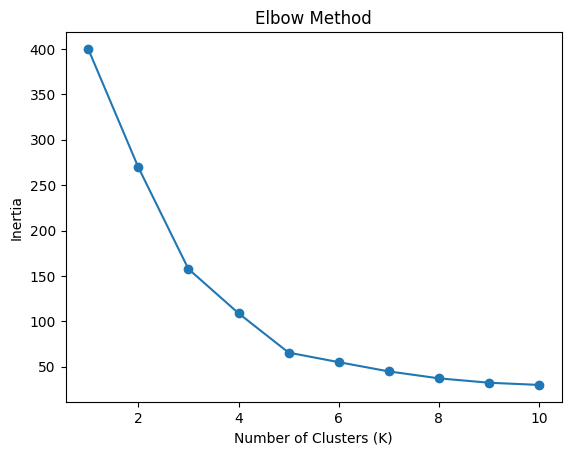


Data with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


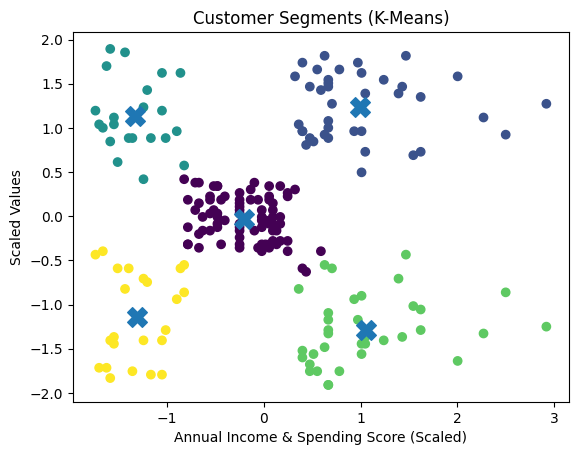


Cluster Summary (Mean Values):
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043

Evaluation Metrics:
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


In [3]:
#  Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#  Upload Dataset
from google.colab import files
uploaded = files.upload()

# Replace filename if needed
data = pd.read_csv("/content/Mall_Customers (1).csv")

print("VETTRI SELVAN D - 24BAD127")

print("\nDataset Preview:")
print(data.head())

#  Data Preprocessing
print("\nChecking Missing Values:")
print(data.isnull().sum())

data = data.dropna()

#  Select Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

#  Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Apply K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assign Cluster Labels
data['Cluster'] = clusters
print("\nData with Cluster Labels:")
print(data.head())

# Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income & Spending Score (Scaled)")
plt.ylabel("Scaled Values")
plt.show()

# Cluster Summary
print("\nCluster Summary (Mean Values):")
print(data.groupby('Cluster').mean(numeric_only=True))

# Evaluation Metrics
print("\nEvaluation Metrics:")
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

SCENARIO 2 – CLUSTERING USING GMM

**Problem Statement**

Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

Dataset (Same / Alternative Dataset)
Same dataset (or any numerical dataset)

**Target Variable:**

Cluster probabilities and labels


**Input Features**


• Annual Income


• Spending Score


• Age (optional)

**IN-LAB TASKS**

1.	Load dataset
2.	Perform preprocessing and scaling
3.	Apply Gaussian Mixture Model (GMM)
4.	Choose number of components (clusters)
5.	Fit model using Expectation-Maximization (EM)
6.	Predict cluster probabilities
7.	Assign clusters based on highest probability
8.	Compare with K-Means clustering

**Evaluation Metrics**

• Log-Likelihood

• AIC (Akaike Information Criterion)

• BIC (Bayesian Information Criterion)

• Silhouette Score


**Analysis Tasks**

• Compare soft vs hard clustering

• Analyze overlapping clusters

• Observe cluster shapes (elliptical vs spherical)

• Compare flexibility with K-Means

**Visualization**

• Cluster probability distribution

• GMM contour plots

• Comparison plot (K-Means vs GMM)


Saving Mall_Customers.csv to Mall_Customers (4).csv
VETTRI SELVAN D - 24BAD127

Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Checking Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data with GMM Clusters:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16     

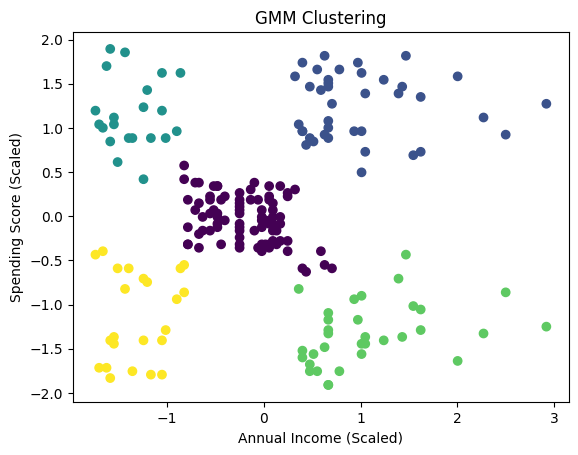


GMM Evaluation Metrics:
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


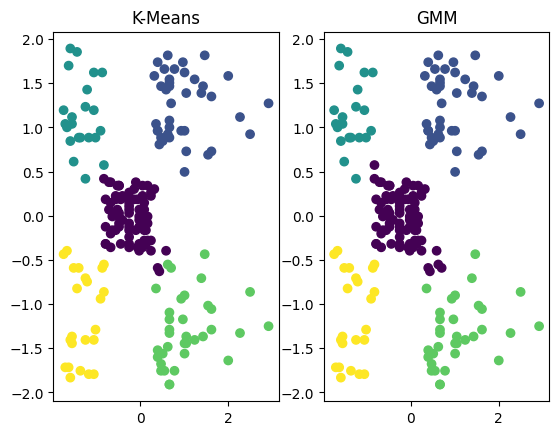


GMM Cluster Summary:
             CustomerID        Age  Annual Income (k$)  \
GMM_Cluster                                              
0             87.452381  42.714286           55.642857   
1            162.000000  32.692308           86.538462   
2             22.000000  25.333333           25.095238   
3            165.000000  40.454545           88.818182   
4             23.000000  45.217391           26.304348   

             Spending Score (1-100)  KMeans_Cluster  
GMM_Cluster                                          
0                         49.369048        0.095238  
1                         82.128205        1.000000  
2                         80.047619        2.000000  
3                         16.000000        3.000000  
4                         20.913043        4.000000  


In [4]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Upload Dataset
from google.colab import files
uploaded = files.upload()

# Load Dataset
data = pd.read_csv("/content/Mall_Customers (1).csv")

print("VETTRI SELVAN D - 24BAD127")

print("\nDataset Preview:")
print(data.head())

# Preprocessing
print("\nChecking Missing Values:")
print(data.isnull().sum())

data = data.dropna()

# Feature Selection
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose number of clusters
k = 5

gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X_scaled)

# Probabilities
probs = gmm.predict_proba(X_scaled)

# Assign clusters
clusters_gmm = np.argmax(probs, axis=1)
data['GMM_Cluster'] = clusters_gmm

print("\nData with GMM Clusters:")
print(data.head())

# Visualization - GMM
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

print("\nGMM Evaluation Metrics:")
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters_gmm))

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

data['KMeans_Cluster'] = clusters_kmeans

# Comparison Plot
plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans)
plt.title("K-Means")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.title("GMM")

plt.show()

print("\nGMM Cluster Summary:")
print(data.groupby('GMM_Cluster').mean(numeric_only=True))